# Лабораторная работа №7
## Анализ и прогнозирование временного ряда

**Цель:** изучение основных методов анализа и прогнозирования временных рядов.

**Датасет:** Stock Price — исторические данные цен акций (регрессия по времени).

---

## Импорт библиотек и загрузка данных

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from gplearn.genetic import SymbolicRegressor
from gplearn.fitness import mean_absolute_error as gp_mae

# import tensorflow as tf
# from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

## Загрузка и подготовка данных

In [29]:
# Загрузка данных цен акций Apple за 5 лет
print("Загрузка данных цен акций Apple (AAPL)...")
df = yf.download('AAPL', start='2019-01-01', end='2024-01-01', progress=False)
df = df[['Close']].reset_index()
df.columns = ['Date', 'Price']

print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nПоследние 5 строк:")
print(df.tail())

Загрузка данных цен акций Apple (AAPL)...
Размер датасета: (1258, 2)

Первые 5 строк:
        Date      Price
0 2019-01-02  37.469200
1 2019-01-03  33.737003
2 2019-01-04  35.177200
3 2019-01-07  35.098900
4 2019-01-08  35.768009

Последние 5 строк:
           Date       Price
1253 2023-12-22  191.433105
1254 2023-12-26  190.889267
1255 2023-12-27  190.988129
1256 2023-12-28  191.413315
1257 2023-12-29  190.375076


In [30]:
# Описательная статистика
print("\nОписательная статистика цены акции:")
print(df['Price'].describe())


Описательная статистика цены акции:
count    1258.000000
mean      120.208070
std        46.294312
min        33.737003
25%        74.547121
50%       131.173096
75%       156.442139
max       195.892609
Name: Price, dtype: float64


## Визуализация временного ряда

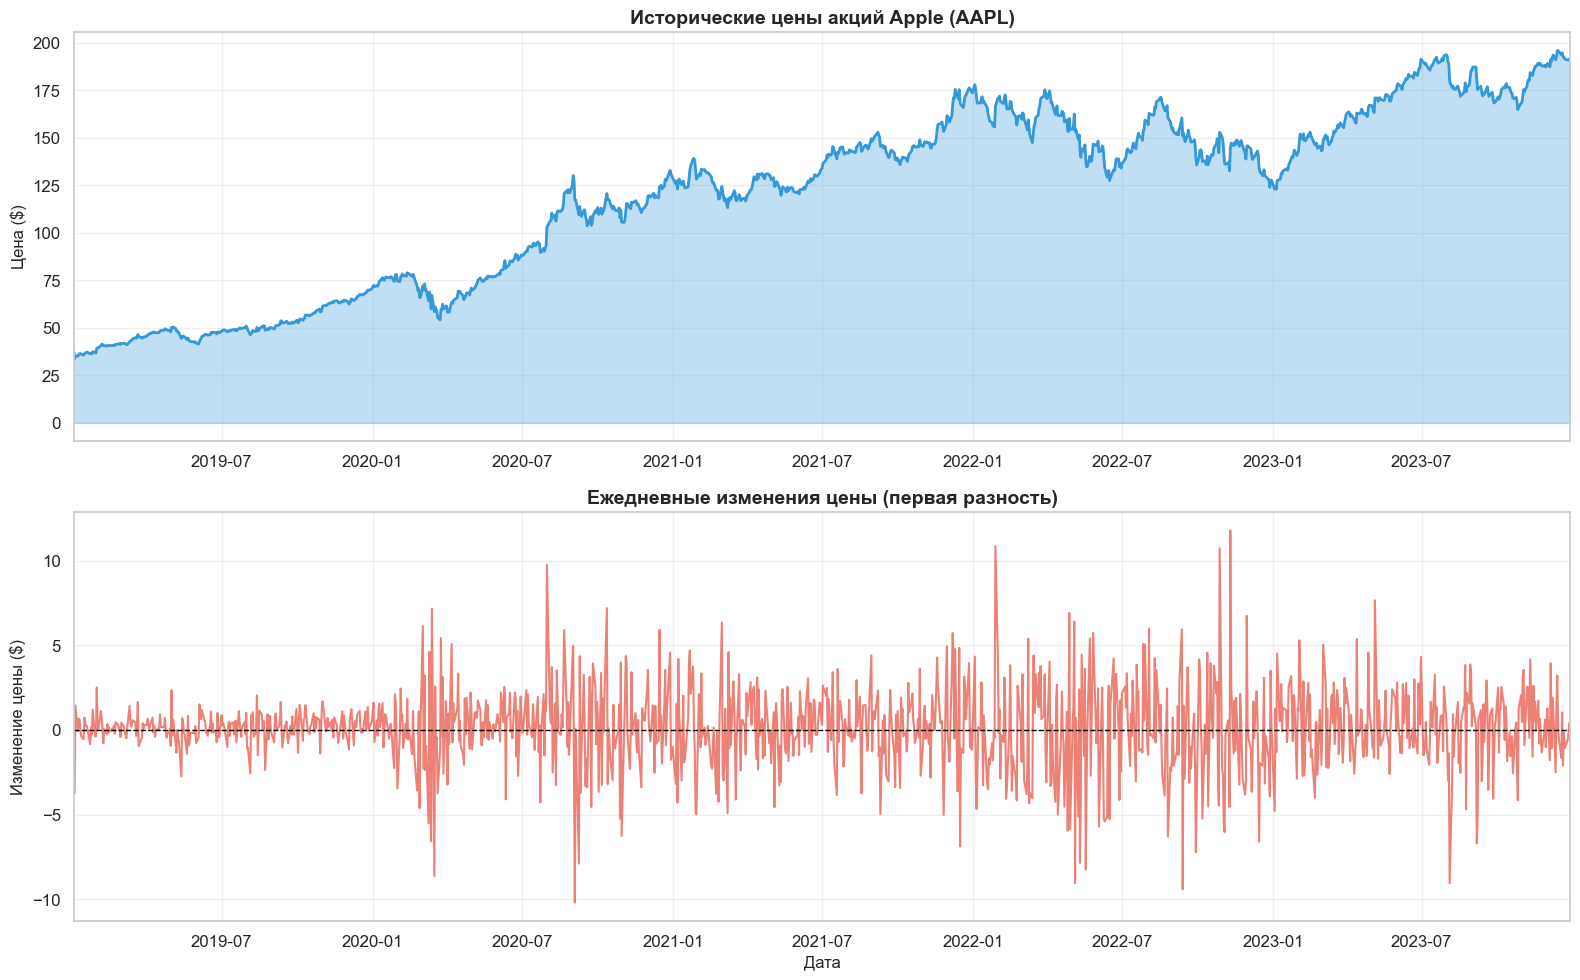

In [31]:
# Полная визуализация временного ряда
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# График цены
axes[0].plot(df['Date'], df['Price'], linewidth=2, color='#3498db')
axes[0].fill_between(df['Date'], df['Price'], alpha=0.3, color='#3498db')
axes[0].set_title('Исторические цены акций Apple (AAPL)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Цена ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(df['Date'].min(), df['Date'].max())

# График изменения цены (первая разность)
price_diff = df['Price'].diff().dropna()
axes[1].plot(df['Date'][1:], price_diff, linewidth=1.5, color='#e74c3c', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Ежедневные изменения цены (первая разность)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата', fontsize=12)
axes[1].set_ylabel('Изменение цены ($)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(df['Date'].min(), df['Date'].max())

plt.tight_layout()
plt.show()

In [32]:
# Проверка стационарности (Augmented Dickey-Fuller тест)
print("\n" + "=" * 70)
print("Тест стационарности (Augmented Dickey-Fuller)")
print("=" * 70)

adf_result = adfuller(df['Price'], autolag='AIC')
print(f'ADF Statistic: {adf_result[0]:.6f}')
print(f'p-value: {adf_result[1]:.6f}')
print(f'Критическое значение (5%): {adf_result[4]["5%"]:.3f}')

if adf_result[1] <= 0.05:
    print("✓ Ряд СТАЦИОНАРЕН (можно использовать AR/MA)")
else:
    print("✗ Ряд НЕ СТАЦИОНАРЕН (требуется дифференцирование)")


Тест стационарности (Augmented Dickey-Fuller)
ADF Statistic: -1.205000
p-value: 0.671441
Критическое значение (5%): -2.864
✗ Ряд НЕ СТАЦИОНАРЕН (требуется дифференцирование)


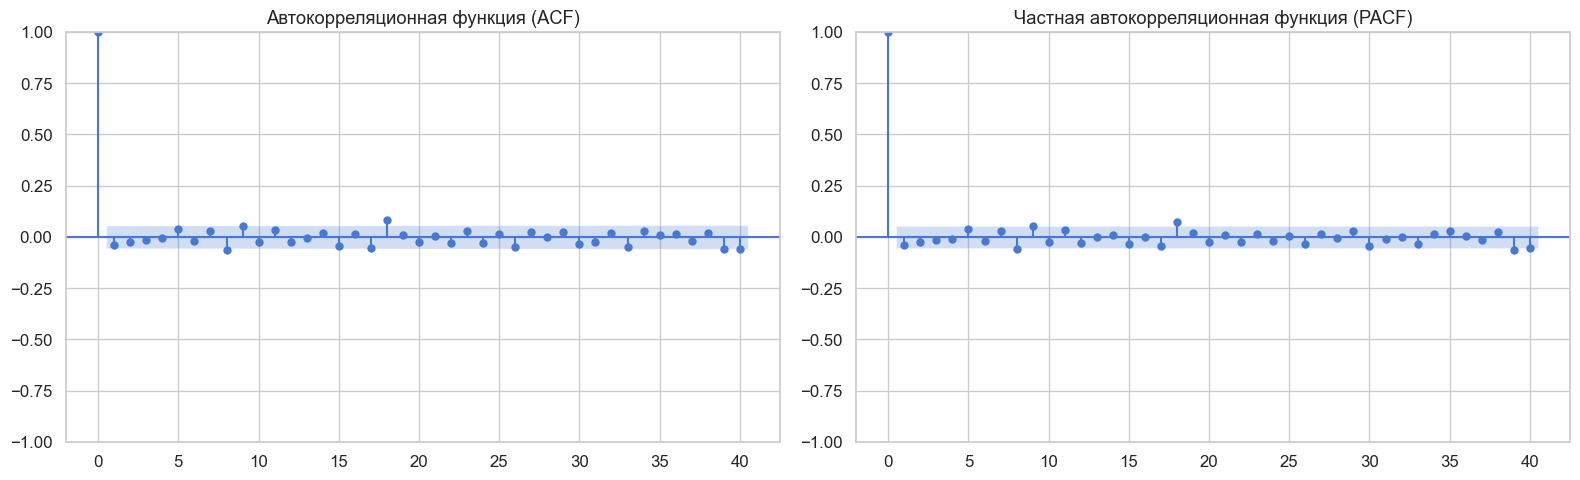

In [33]:
# ACF и PACF графики
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(price_diff, lags=40, ax=axes[0], title='Автокорреляционная функция (ACF)')
plot_pacf(price_diff, lags=40, ax=axes[1], title='Частная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

## Подготовка данных для моделей

In [34]:
# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_price = scaler.fit_transform(df[['Price']])

# Разделение на обучение и тестирование (80-20)
train_size = int(len(scaled_price) * 0.8)
train_data = scaled_price[:train_size]
test_data = scaled_price[train_size:]

train_date = df['Date'][:train_size]
test_date = df['Date'][train_size:]

print(f"Размер обучающего набора: {len(train_data)} дней ({train_date.iloc[0].date()} - {train_date.iloc[-1].date()})")
print(f"Размер тестового набора: {len(test_data)} дней ({test_date.iloc[0].date()} - {test_date.iloc[-1].date()})")

Размер обучающего набора: 1006 дней (2019-01-02 - 2022-12-28)
Размер тестового набора: 252 дней (2022-12-29 - 2023-12-29)


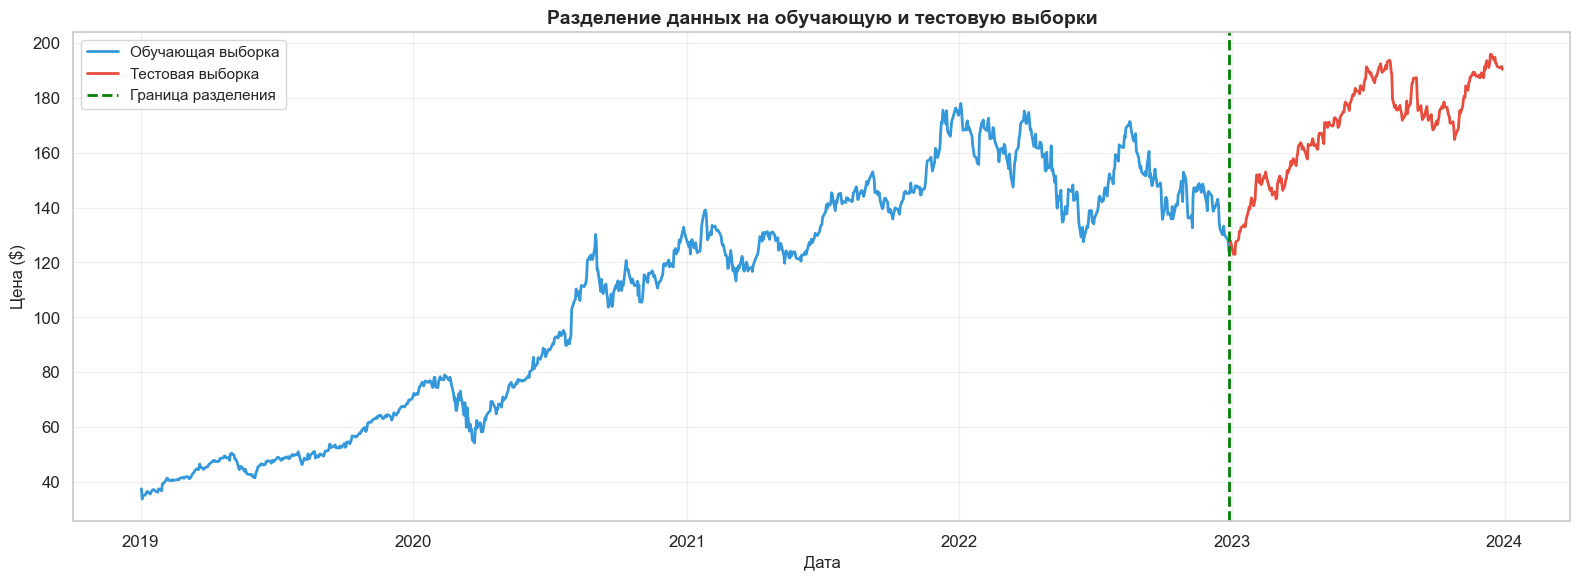

In [35]:
# Визуализация разделения данных
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(train_date, df['Price'][:train_size], label='Обучающая выборка', linewidth=2, color='#3498db')
ax.plot(test_date, df['Price'][train_size:], label='Тестовая выборка', linewidth=2, color='#e74c3c')
ax.axvline(x=train_date.iloc[-1], color='green', linestyle='--', linewidth=2, label='Граница разделения')

ax.set_title('Разделение данных на обучающую и тестовую выборки', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Цена ($)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1. ARIMA модель (Авторегрессионная интегрированная модель скользящего среднего)

In [60]:
print("\n" + "=" * 70)
print("ARIMA модель")
print("=" * 70)

# Обучение ARIMA(5,1,2) - на основе ACF/PACF анализа
arima_model = ARIMA(df['Price'][:train_size], order=(5, 1, 2))
arima_fitted = arima_model.fit()

print(arima_fitted.summary())


ARIMA модель
                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 1006
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -2290.884
Date:                Thu, 14 May 2026   AIC                           4597.769
Time:                        11:52:38   BIC                           4637.071
Sample:                             0   HQIC                          4612.703
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7634      0.086    -20.568      0.000      -1.931      -1.595
ar.L2         -0.9546      0.096     -9.977      0.000      -1.142      -0.767
ar.L3         -0.1340      0.059     -

In [61]:
# Прогнозирование на тестовом наборе
arima_forecast = arima_fitted.forecast(steps=len(test_data))
y_pred_arima = arima_forecast

# Оценка качества
mse_arima = mean_squared_error(df['Price'][train_size:], y_pred_arima)
mae_arima = mean_absolute_error(df['Price'][train_size:], y_pred_arima)
rmse_arima = np.sqrt(mse_arima)
r2_arima = r2_score(df['Price'][train_size:], y_pred_arima)
mape_arima = mean_absolute_percentage_error(df['Price'][train_size:], y_pred_arima)

print(f"\nARIMA(5,1,2) результаты:")
print(f"  MSE: {mse_arima:.4f}")
print(f"  MAE: {mae_arima:.4f}")
print(f"  RMSE: {rmse_arima:.4f}")
print(f"  MAPE: {mape_arima:.4f}%")
print(f"  R²: {r2_arima:.4f}")


ARIMA(5,1,2) результаты:
  MSE: 2382.3491
  MAE: 45.5442
  RMSE: 48.8093
  MAPE: 0.2595%
  R²: -6.6778


## 2. Символьная регрессия (Genetic Programming)

In [38]:
print("\n" + "=" * 70)
print("Символьная регрессия (Genetic Programming)")
print("=" * 70)

# Подготовка данных для символьной регрессии
# Создаём лаговые переменные (используем последние 10 дней)
lags = 10
X_train_gp = []
y_train_gp = []

for i in range(lags, len(train_data)):
    X_train_gp.append(train_data[i-lags:i].flatten())
    y_train_gp.append(train_data[i].flatten()[0])

X_train_gp = np.array(X_train_gp)
y_train_gp = np.array(y_train_gp)

print(f"Размер обучающего набора (GP): {X_train_gp.shape}")


Символьная регрессия (Genetic Programming)
Размер обучающего набора (GP): (996, 10)


In [39]:
# Обучение символьной регрессии
print("\nОбучение Genetic Programming модели...")
gp_model = SymbolicRegressor(
    population_size=300,
    generations=50,
    stopping_criteria=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    metric=gp_mae
)

gp_model.fit(X_train_gp, y_train_gp)

print(f"\n✓ Обучение завершено!")
print(f"Лучшее уравнение: {gp_model}")


Обучение Genetic Programming модели...
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    24.41          9432.49        5        0.0181467        0.0192197      1.02m
   1     8.19          1.03256        1        0.0101906        0.0110359      2.31s
   2     4.01         0.412043        1        0.0100338        0.0124403      2.50s
   3     1.48         0.063082        1       0.00997881        0.0129334      2.44s

✓ Обучение завершено!
Лучшее уравнение: X9


In [40]:
# Прогнозирование на тестовом наборе
X_test_gp = []
for i in range(lags, len(train_data) + len(test_data)):
    if i < len(scaled_price):
        X_test_gp.append(scaled_price[i-lags:i].flatten())

X_test_gp = np.array(X_test_gp)
y_pred_gp_scaled = gp_model.predict(X_test_gp[-len(test_data):])

# Денормализация
y_pred_gp = scaler.inverse_transform(y_pred_gp_scaled.reshape(-1, 1)).flatten()

# Оценка качества
mse_gp = mean_squared_error(df['Price'][train_size:], y_pred_gp)
mae_gp = mean_absolute_error(df['Price'][train_size:], y_pred_gp)
rmse_gp = np.sqrt(mse_gp)
r2_gp = r2_score(df['Price'][train_size:], y_pred_gp)
mape_gp = mean_absolute_percentage_error(df['Price'][train_size:], y_pred_gp)

print(f"\nСимвольная регрессия результаты:")
print(f"  MSE: {mse_gp:.4f}")
print(f"  MAE: {mae_gp:.4f}")
print(f"  RMSE: {rmse_gp:.4f}")
print(f"  MAPE: {mape_gp:.4f}%")
print(f"  R²: {r2_gp:.4f}")


Символьная регрессия результаты:
  MSE: 4.5250
  MAE: 1.6416
  RMSE: 2.1272
  MAPE: 0.0099%
  R²: 0.9854


## 3. LSTM модель (Long Short-Term Memory)

In [41]:
print("\n" + "=" * 70)
print("LSTM модель (Long Short-Term Memory)")
print("=" * 70)

# Подготовка данных для LSTM
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60

X_train_lstm, y_train_lstm = create_sequences(train_data, seq_length)
X_test_lstm, y_test_lstm = create_sequences(scaled_price[train_size-seq_length:], seq_length)

print(f"LSTM обучающий набор: X={X_train_lstm.shape}, y={y_train_lstm.shape}")
print(f"LSTM тестовый набор: X={X_test_lstm.shape}, y={y_test_lstm.shape}")


LSTM модель (Long Short-Term Memory)
LSTM обучающий набор: X=(946, 60, 1), y=(946, 1)
LSTM тестовый набор: X=(252, 60, 1), y=(252, 1)


In [42]:
# Построение LSTM модели
print("\nПостроение LSTM архитектуры...")
lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

print(lstm_model.summary())


Построение LSTM архитектуры...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

None


In [43]:
# Обучение LSTM
print("\nОбучение LSTM модели...")
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

print(f"✓ Обучение завершено! Обучено эпох: {len(history.history['loss'])}")


Обучение LSTM модели...
✓ Обучение завершено! Обучено эпох: 100


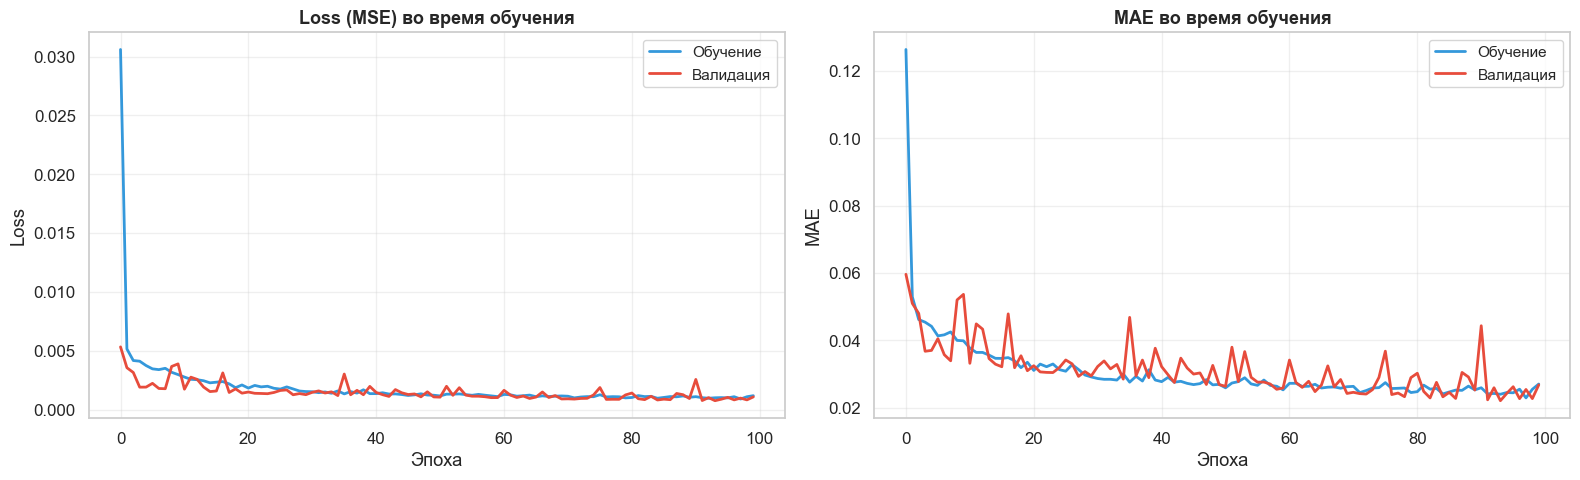

In [44]:
# График истории обучения
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['loss'], label='Обучение', linewidth=2, color='#3498db')
axes[0].plot(history.history['val_loss'], label='Валидация', linewidth=2, color='#e74c3c')
axes[0].set_title('Loss (MSE) во время обучения', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Обучение', linewidth=2, color='#3498db')
axes[1].plot(history.history['val_mae'], label='Валидация', linewidth=2, color='#e74c3c')
axes[1].set_title('MAE во время обучения', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# Прогнозирование на тестовом наборе
print("\nПрогнозирование на тестовом наборе...")
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)

# Денормализация
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).flatten()

# Оценка качества
mse_lstm = mean_squared_error(df['Price'][train_size:], y_pred_lstm)
mae_lstm = mean_absolute_error(df['Price'][train_size:], y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)
r2_lstm = r2_score(df['Price'][train_size:], y_pred_lstm)
mape_lstm = mean_absolute_percentage_error(df['Price'][train_size:], y_pred_lstm)

print(f"\nLSTM результаты:")
print(f"  MSE: {mse_lstm:.4f}")
print(f"  MAE: {mae_lstm:.4f}")
print(f"  RMSE: {rmse_lstm:.4f}")
print(f"  MAPE: {mape_lstm:.4f}%")
print(f"  R²: {r2_lstm:.4f}")


Прогнозирование на тестовом наборе...

LSTM результаты:
  MSE: 27.5100
  MAE: 4.5315
  RMSE: 5.2450
  MAPE: 0.0262%
  R²: 0.9113


## Сравнение моделей

In [46]:
# Создание сводной таблицы
results = pd.DataFrame({
    'Модель': ['ARIMA(5,1,2)', 'Символьная регрессия', 'LSTM'],
    'MSE': [mse_arima, mse_gp, mse_lstm],
    'MAE': [mae_arima, mae_gp, mae_lstm],
    'RMSE': [rmse_arima, rmse_gp, rmse_lstm],
    'MAPE (%)': [mape_arima, mape_gp, mape_lstm],
    'R²': [r2_arima, r2_gp, r2_lstm]
})

print("\n" + "=" * 110)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 110)
print(results.to_string(index=False))
print("=" * 110)

# Лучшая модель
best_mae_idx = results['MAE'].idxmin()
best_r2_idx = results['R²'].idxmax()

print(f"\n🏆 Лучшая по MAE: {results.loc[best_mae_idx, 'Модель']} (MAE={results.loc[best_mae_idx, 'MAE']:.4f})")
print(f"🏆 Лучшая по R²: {results.loc[best_r2_idx, 'Модель']} (R²={results.loc[best_r2_idx, 'R²']:.4f})")


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
              Модель         MSE       MAE      RMSE  MAPE (%)        R²
        ARIMA(5,1,2) 2386.498305 45.587129 48.851799  0.259700 -6.691190
Символьная регрессия    4.525001  1.641601  2.127205  0.009861  0.985417
                LSTM   27.510046  4.531535  5.245002  0.026169  0.911341

🏆 Лучшая по MAE: Символьная регрессия (MAE=1.6416)
🏆 Лучшая по R²: Символьная регрессия (R²=0.9854)


## Визуализация прогнозов

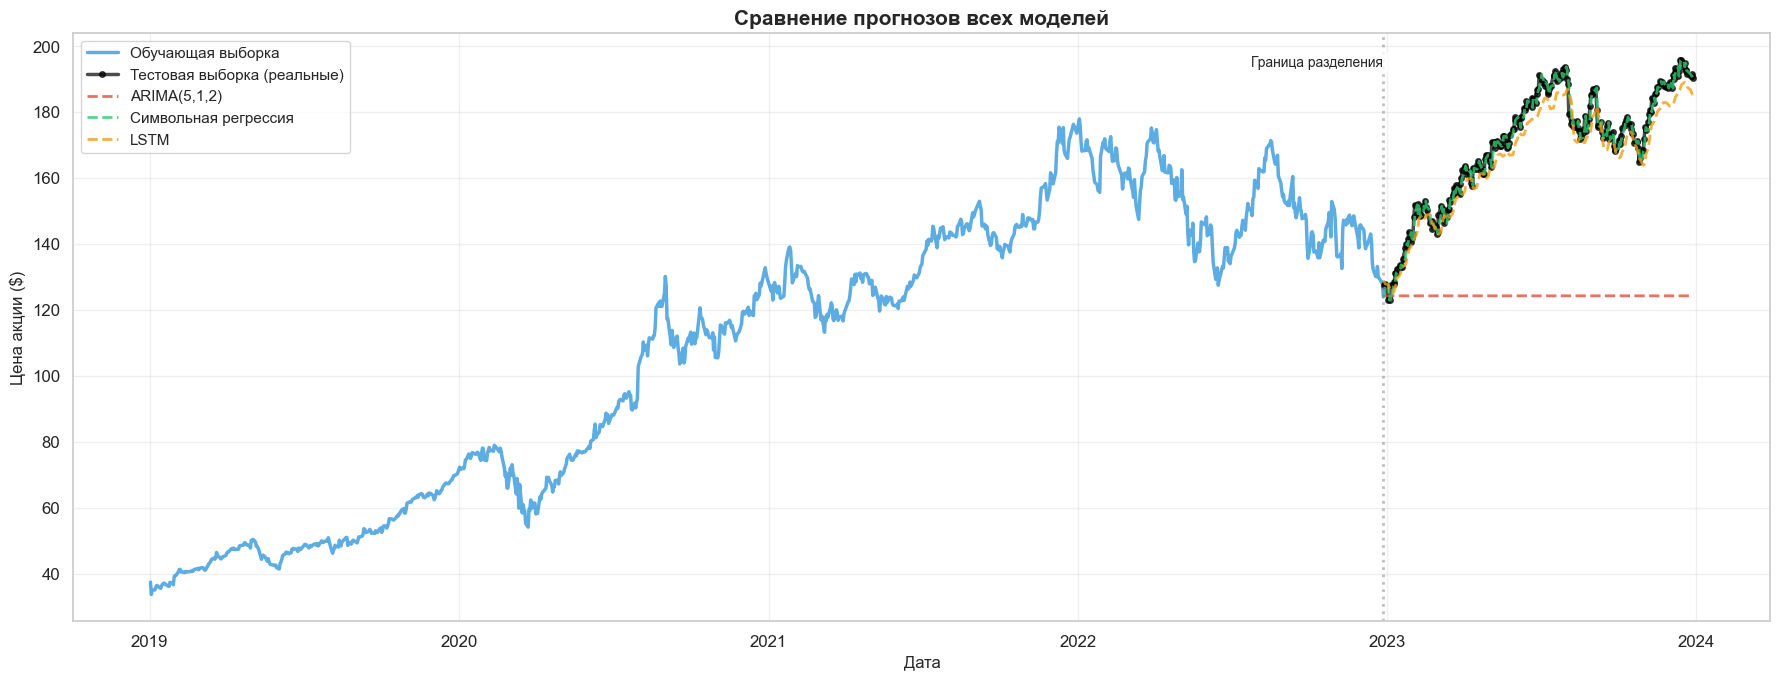

<Figure size 1400x600 with 0 Axes>

In [47]:
# Визуализация всех прогнозов
fig, ax = plt.subplots(figsize=(18, 7))

# Исторические данные
ax.plot(train_date, df['Price'][:train_size], label='Обучающая выборка', 
        linewidth=2.5, color='#3498db', alpha=0.8)

# Тестовая выборка
ax.plot(test_date, df['Price'][train_size:], label='Тестовая выборка (реальные)', 
        linewidth=2.5, color='black', marker='o', markersize=4, alpha=0.7)

# Прогнозы ARIMA
ax.plot(test_date, y_pred_arima, label='ARIMA(5,1,2)', 
        linewidth=2, color='#e74c3c', linestyle='--', alpha=0.8)

# Прогнозы Символьная регрессия
ax.plot(test_date, y_pred_gp, label='Символьная регрессия', 
        linewidth=2, color='#2ecc71', linestyle='--', alpha=0.8)

# Прогнозы LSTM
test_date_lstm = test_date.iloc[:].reset_index(drop=True)
ax.plot(test_date_lstm, y_pred_lstm, label='LSTM', 
        linewidth=2, color='#f39c12', linestyle='--', alpha=0.8)

ax.axvline(x=train_date.iloc[-1], color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax.text(train_date.iloc[-1], ax.get_ylim()[1]*0.95, 'Граница разделения', 
        fontsize=10, ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Сравнение прогнозов всех моделей', fontsize=15, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Цена акции ($)', fontsize=12)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('all_predictions_comparison.png', dpi=300, bbox_inches='tight')

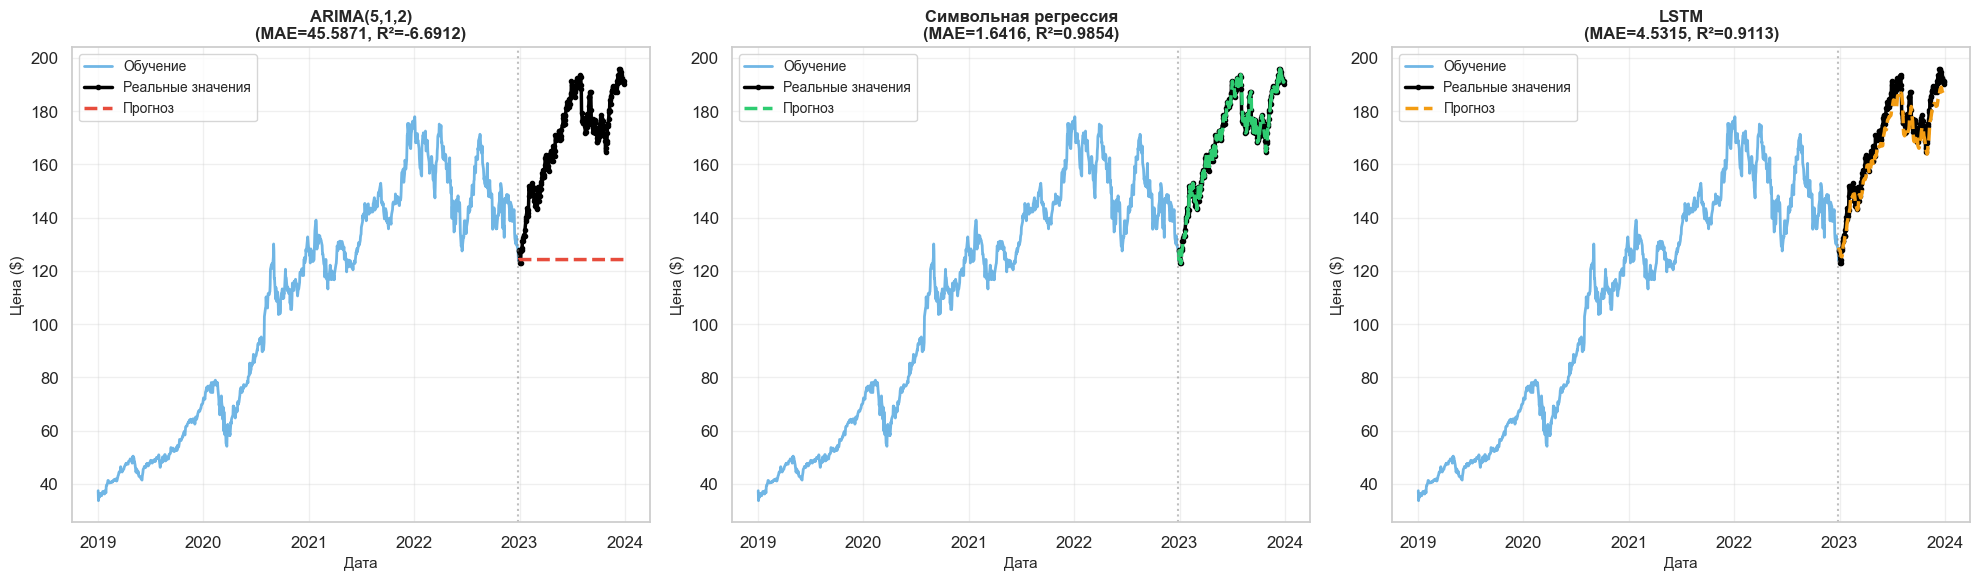

<Figure size 1400x600 with 0 Axes>

In [48]:
# Отдельные графики для каждой модели
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_models = ['#e74c3c', '#2ecc71', '#f39c12']
model_names = ['ARIMA(5,1,2)', 'Символьная регрессия', 'LSTM']
predictions = [y_pred_arima, y_pred_gp, y_pred_lstm]
test_dates = [test_date, test_date, test_date_lstm]

for idx, (ax, name, pred, color, dates) in enumerate(zip(axes, model_names, predictions, colors_models, test_dates)):
    ax.plot(train_date, df['Price'][:train_size], label='Обучение', 
            linewidth=2, color='#3498db', alpha=0.7)
    ax.plot(test_date, df['Price'][train_size:], label='Реальные значения', 
            linewidth=2.5, color='black', marker='o', markersize=3)
    ax.plot(dates, pred, label='Прогноз', linewidth=2.5, color=color, linestyle='--')
    
    ax.axvline(x=train_date.iloc[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.set_title(f'{name}\n(MAE={results.iloc[idx]["MAE"]:.4f}, R²={results.iloc[idx]["R²"]:.4f})', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Дата', fontsize=11)
    ax.set_ylabel('Цена ($)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('individual_predictions.png', dpi=300, bbox_inches='tight')

## Анализ ошибок прогнозирования

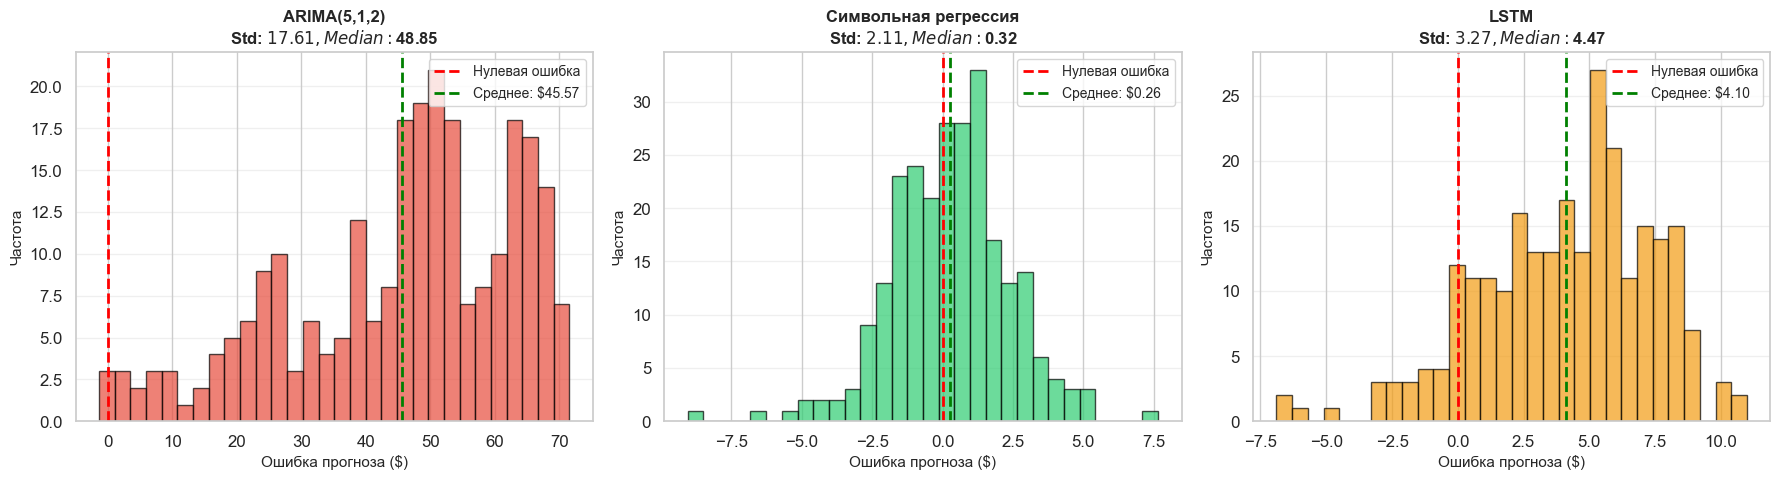

<Figure size 1400x600 with 0 Axes>

In [49]:
# Расчет ошибок
errors_arima = df['Price'][train_size:].values - y_pred_arima
errors_gp = df['Price'][train_size:].values - y_pred_gp
errors_lstm = df['Price'][train_size:].values - y_pred_lstm

# Визуализация ошибок
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (ax, errors, name, color) in enumerate(zip(
    axes, 
    [errors_arima, errors_gp, errors_lstm],
    model_names,
    colors_models
)):
    ax.hist(errors, bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
    ax.axvline(x=np.mean(errors), color='green', linestyle='--', linewidth=2, 
               label=f'Среднее: ${np.mean(errors):.2f}')
    
    ax.set_title(f'{name}\nStd: ${np.std(errors):.2f}, Median: ${np.median(errors):.2f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Ошибка прогноза ($)', fontsize=11)
    ax.set_ylabel('Частота', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')

## Сравнение метрик качества

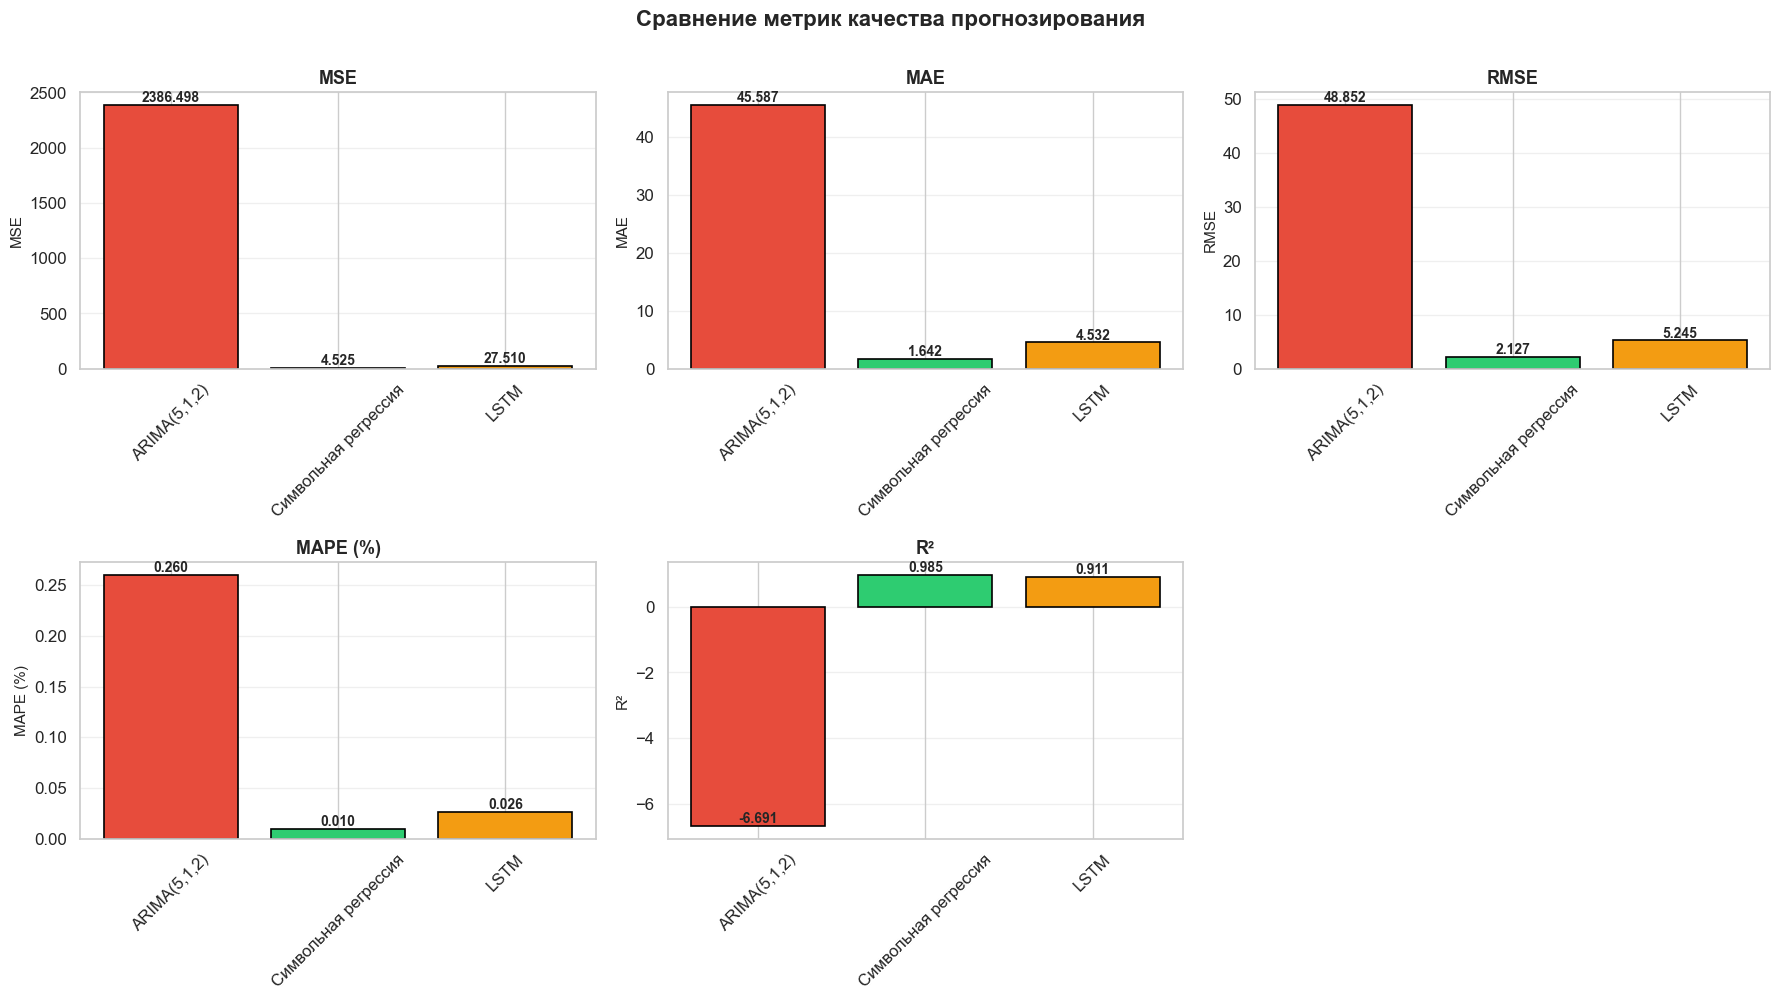

<Figure size 1400x600 with 0 Axes>

In [50]:
# Визуализация метрик
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['MSE', 'MAE', 'RMSE', 'MAPE (%)', 'R²']
colors = ['#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    values = results[metric].values
    bars = ax.bar(results['Модель'], values, color=colors, edgecolor='black', linewidth=1.2)
    
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax.tick_params(axis='x', rotation=45)

# Удаляем пустой подграфик
fig.delaxes(axes[-1])

fig.suptitle('Сравнение метрик качества прогнозирования', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')